# Delivery Time Prediction

This notebook builds a regression model to predict **delivery time (in minutes)** based on:
- `distance_km`
- `items`
- `traffic_level`
- `preparation_minutes`

**Workflow:** Load data → Explore → Clean → Preprocess → Train models → Evaluate → Compare → Predict on new data.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 5)
RANDOM_STATE = 42

## 2. Load Data

In [2]:
df = pd.read_csv('delivery_time.csv')
print(df.shape)
df.head(10)

(1020, 5)


,distance_km,items,traffic_level,preparation_minutes,delivery_minutes
0,37.2,4.0,2.0,10.0,108.7
1,30.5,10.0,4.0,31.0,134.8
2,13.7,3.0,1.0,60.0,67.5
3,9.0,9.0,3.0,9.0,61.0
4,12.4,NaN,2.0,57.0,78.5
5,16.0,2.0,3.0,49.0,80.6
6,26.7,1.0,3.0,54.0,111.5
7,11.1,3.0,4.0,57.0,89.4
8,27.1,3.0,3.0,31.0,104.8
9,32.9,6.0,5.0,49.0,128.6


## 3. Explore the Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   distance_km          1010 non-null   float64
 1   items                1010 non-null   float64
 2   traffic_level        1010 non-null   float64
 3   preparation_minutes  1010 non-null   float64
 4   delivery_minutes     1020 non-null   float64
dtypes: float64(5)
memory usage: 40.0 KB


In [4]:
df.describe()

,distance_km,items,traffic_level,preparation_minutes,delivery_minutes
count,1010.000000,1010.000000,1010.000000,1010.000000,1020.000000
mean,20.412178,5.419802,3.093069,33.649505,93.846863
std,11.535096,2.893553,1.500331,16.274404,26.351366
min,-10.000000,-2.000000,1.000000,5.000000,33.700000
25%,10.900000,3.000000,2.000000,20.000000,73.800000
50%,20.650000,5.000000,3.000000,34.000000,93.700000
75%,30.700000,8.000000,4.000000,48.000000,113.625000
max,39.800000,10.000000,10.000000,60.000000,156.400000


In [5]:
# Missing values
df.isna().sum()

distance_km            10
items                  10
traffic_level          10
preparation_minutes    10
delivery_minutes        0
dtype: int64

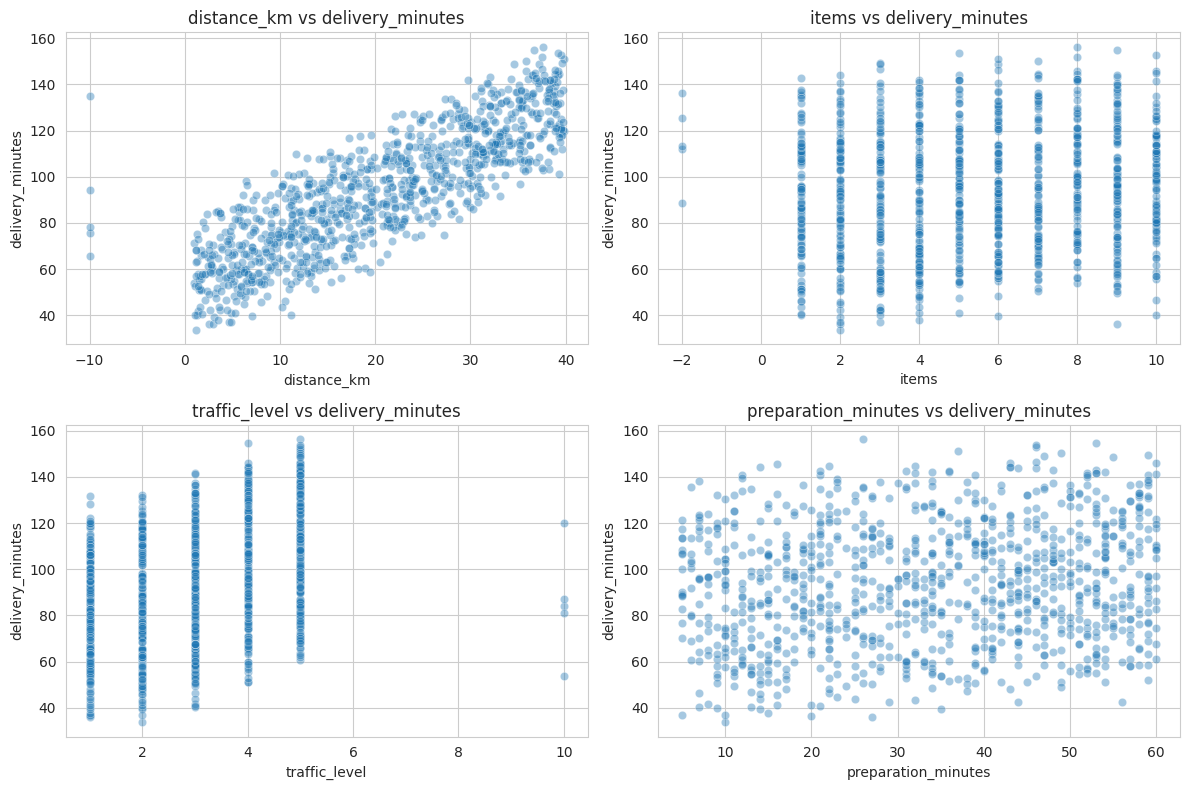

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['distance_km', 'items', 'traffic_level', 'preparation_minutes']
for ax, col in zip(axes.ravel(), features):
    sns.scatterplot(data=df, x=col, y='delivery_minutes', ax=ax, alpha=0.4)
    ax.set_title(f'{col} vs delivery_minutes')
plt.tight_layout()
plt.show()

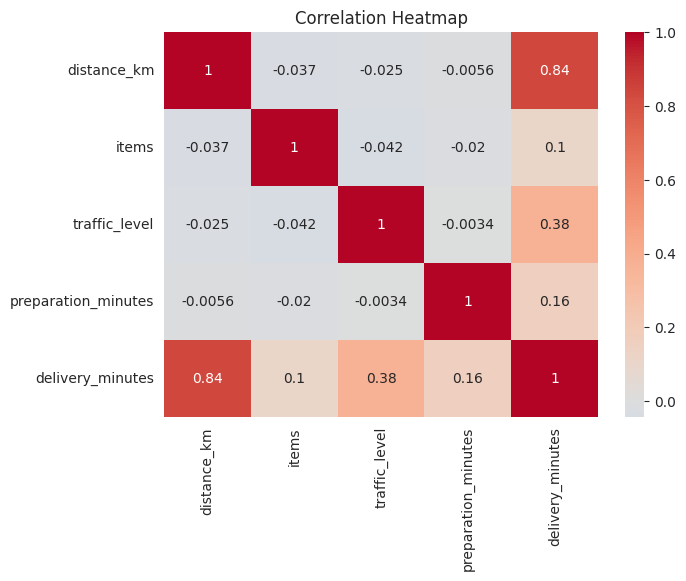

In [7]:
sns.heatmap(df[features + ['delivery_minutes']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

## 4. Data Cleaning

The exploration reveals a few data quality issues:
- Some **missing values** across the feature columns.
- `distance_km` has **negative values** (impossible).
- `items` has **negative values** (impossible — you can't order negative items).
- `traffic_level` should range **1–5**, but a few rows show `10` (invalid).

We convert invalid values to `NaN`, then impute using the median.

In [8]:
df_clean = df.copy()

df_clean.loc[df_clean['distance_km'] < 0, 'distance_km'] = np.nan
df_clean.loc[df_clean['items'] < 0, 'items'] = np.nan
df_clean.loc[df_clean['traffic_level'] > 5, 'traffic_level'] = np.nan
df_clean.loc[df_clean['traffic_level'] < 1, 'traffic_level'] = np.nan

print('Remaining missing values per column:')
df_clean.isna().sum()

Remaining missing values per column:


distance_km            15
items                  15
traffic_level          15
preparation_minutes    10
delivery_minutes        0
dtype: int64

## 5. Train/Test Split

In [9]:
X = df_clean[features]
y = df_clean['delivery_minutes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (816, 4)
Test shape : (204, 4)


## 6. Preprocessing + Model Pipelines

In [10]:
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)
}

pipelines = {
    name: Pipeline(steps=[('preprocess', preprocessor), ('model', model)])
    for name, model in models.items()
}
pipelines

{'Linear Regression': Pipeline(steps=[('preprocess',
                  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                  ('scaler', StandardScaler())])),
                 ('model', LinearRegression())]),
 'Decision Tree': Pipeline(steps=[('preprocess',
                  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                  ('scaler', StandardScaler())])),
                 ('model', DecisionTreeRegressor(random_state=42))]),
 'Random Forest': Pipeline(steps=[('preprocess',
                  Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                  ('scaler', StandardScaler())])),
                 ('model',
                  RandomForestRegressor(n_estimators=300, random_state=42))])}

## 7. Train & Evaluate Models

In [11]:
results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,4.614859,6.493924,0.938414
1,Random Forest,5.558234,7.478909,0.918315
2,Decision Tree,7.799510,10.373503,0.842849


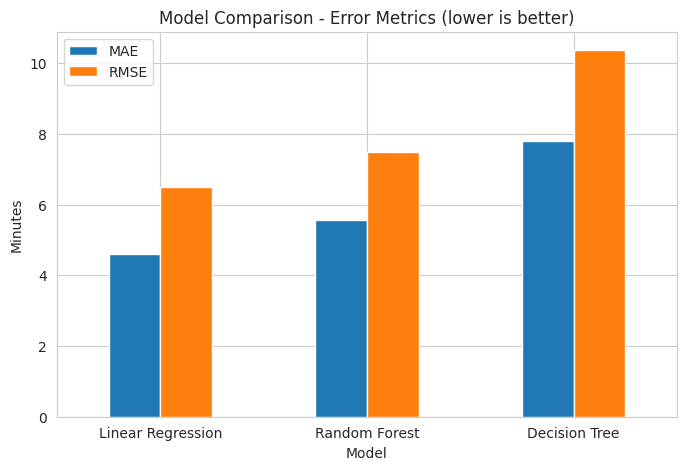

In [12]:
results_df.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(8,5))
plt.title('Model Comparison - Error Metrics (lower is better)')
plt.ylabel('Minutes')
plt.xticks(rotation=0)
plt.show()

## 8. Closer Look at the Best Model

We pick the model with the highest R² (best explained variance) and inspect predicted vs actual values and residuals.

In [13]:
best_name = results_df.iloc[0]['Model']
best_pipe = pipelines[best_name]
print('Best model:', best_name)

preds = best_pipe.predict(X_test)
print(f"MAE:  {mean_absolute_error(y_test, preds):.2f} minutes")
print(f"RMSE: {mean_squared_error(y_test, preds) ** 0.5:.2f} minutes")
print(f"R2:   {r2_score(y_test, preds):.4f}")

Best model: Linear Regression
MAE:  4.61 minutes
RMSE: 6.49 minutes
R2:   0.9384


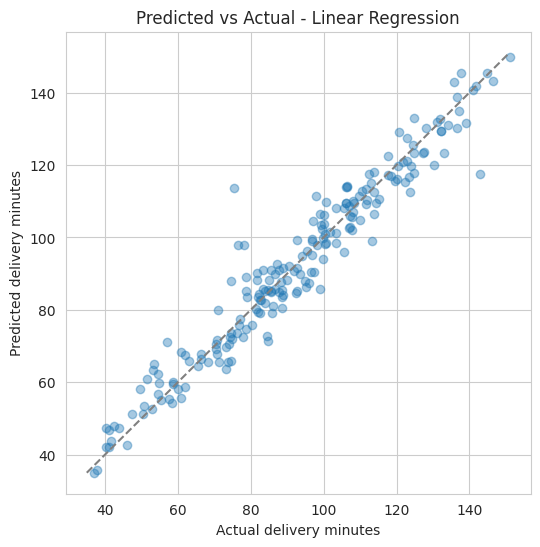

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_test, preds, alpha=0.4)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
ax.plot(lims, lims, '--', color='gray')
ax.set_xlabel('Actual delivery minutes')
ax.set_ylabel('Predicted delivery minutes')
ax.set_title(f'Predicted vs Actual - {best_name}')
plt.show()

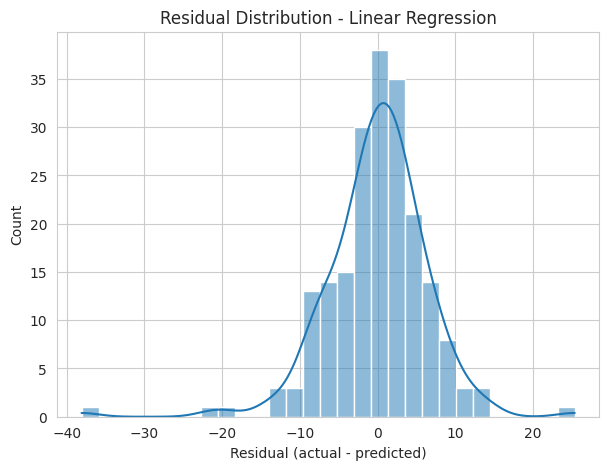

In [15]:
residuals = y_test - preds
sns.histplot(residuals, kde=True)
plt.title(f'Residual Distribution - {best_name}')
plt.xlabel('Residual (actual - predicted)')
plt.show()

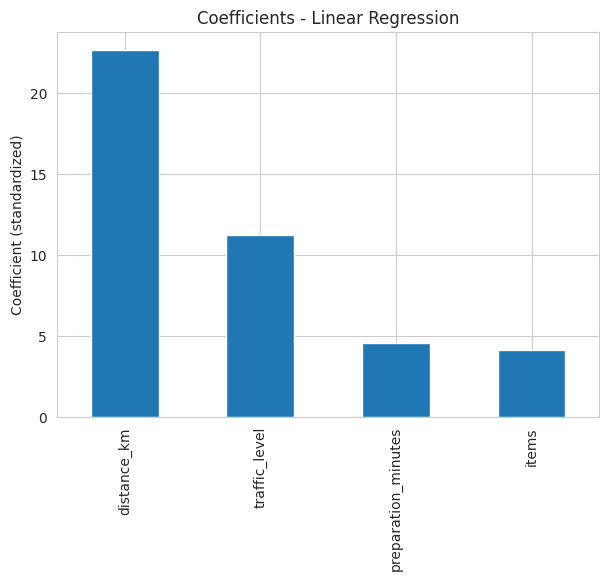

distance_km            22.670911
traffic_level          11.240786
preparation_minutes     4.585546
items                   4.163698
dtype: float64


In [16]:
# Feature importance / coefficients, if available
model_step = best_pipe.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=features).sort_values(ascending=False)
    importances.plot(kind='bar', title=f'Feature Importance - {best_name}')
    plt.ylabel('Importance')
    plt.show()
    print(importances)
elif hasattr(model_step, 'coef_'):
    coefs = pd.Series(model_step.coef_, index=features).sort_values(key=abs, ascending=False)
    coefs.plot(kind='bar', title=f'Coefficients - {best_name}')
    plt.ylabel('Coefficient (standardized)')
    plt.show()
    print(coefs)

## 9. Predict on New / Custom Data

Use the trained pipeline to predict delivery time for new orders. Just edit the values below.

In [17]:
new_orders = pd.DataFrame([
    {'distance_km': 12.5, 'items': 4, 'traffic_level': 2, 'preparation_minutes': 20},
    {'distance_km': 35.0, 'items': 9, 'traffic_level': 5, 'preparation_minutes': 50},
])

new_preds = best_pipe.predict(new_orders)
new_orders['predicted_delivery_minutes'] = new_preds.round(1)
new_orders

,distance_km,items,traffic_level,preparation_minutes,predicted_delivery_minutes
0,12.5,4,2,20,63.2
1,35.0,9,5,50,148.2


## 10. Summary

- Cleaned invalid values (negative distance/items, out-of-range traffic level) and imputed missing data.
- Trained and compared **Linear Regression**, **Decision Tree**, and **Random Forest** regressors.
- Evaluated with MAE, RMSE, and R².
- Inspected predicted-vs-actual plots, residuals, and feature importance for the best model.
- Reused the trained pipeline to predict delivery time for new orders.

**Next steps you could try:** cross-validation, hyperparameter tuning, adding features like time-of-day or weather, or trying gradient boosting models.